#  Comprehensive Earthquake Data Analysis & Predictive Modeling


Bu çalışma, Türkiye’deki tarihsel deprem verileri üzerinde veri ön işleme, keşifsel analiz, zaman serisi modelleme ve makine öğrenmesi yöntemleri uygulanarak gerçekleştirilmiştir.

Amaç; deprem dağılımını analiz etmek, günlük deprem sayısını modellemek ve deprem büyüklüğünü tahmin etmektir.

## Veri Yükleme
Deprem verisi `.txt` formatında olup tab karakteri ile ayrılmıştır.

In [16]:
import pandas as pd

file_path = r"C:\Users\Burhan Yasa\Desktop\depremveri.txt"

df = pd.read_csv(file_path, delimiter="\t", encoding="iso-8859-9")
df.head()

,No,Deprem Kodu,Olus tarihi,Olus zamani,Enlem,Boylam,Der(km),xM,MD,ML,Mw,Ms,Mb,Tip,Yer
0,1,20240330002503,2024.03.30,00:25:03.23,38.4867,39.3500,5.0,4.7,0.0,4.7,4.7,0.0,0.0,Ke,GUNEYKOY-SIVRICE (ELAZIG) [South East 2.9 km]
1,2,20240321192040,2024.03.21,19:20:40.93,39.6440,28.7695,4.3,4.1,0.0,4.1,3.8,0.0,0.0,Ke,ADAOREN-DURSUNBEY (BALIKESIR) [South East 1.5...
2,3,20240320055541,2024.03.20,05:55:41.53,37.4667,36.9563,7.0,4.0,0.0,4.0,3.9,0.0,0.0,Ke,KOCALAR- (KAHRAMANMARAS) [North West 2.2 km]
3,4,20240311001017,2024.03.11,00:10:17.03,41.5363,36.4025,5.0,4.4,0.0,4.4,4.1,0.0,0.0,Ke,TAFLAN ACIKLARI-SAMSUN (KARADENIZ)
4,5,20240310135557,2024.03.10,13:55:57.01,36.0885,30.0495,29.9,4.9,0.0,4.9,4.7,0.0,0.0,Ke,KALE ACIKLARI-ANTALYA (AKDENIZ)


## Veri Ön İşleme

 *Tarih ve saat birleştirildi
 *Analiz için gerekli sütunlar seçildi
 *Zaman indeksi oluşturuldu

In [17]:
df['Olus tarihi'] = df['Olus tarihi'].str.replace('.', '-', regex=False)
df['datetime'] = pd.to_datetime(df['Olus tarihi'] + ' ' + df['Olus zamani'])

df = df[['datetime', 'Enlem', 'Boylam', 'Der(km)', 'Mw']]
df.set_index('datetime', inplace=True)

df.columns = ['Latitude', 'Longitude', 'Depth_km', 'Magnitude']

df = df.dropna(subset=['Magnitude'])

## Keşifsel Veri Analizi

Deprem büyüklüğü ve günlük deprem sayısı dağılımları incelenmiştir.

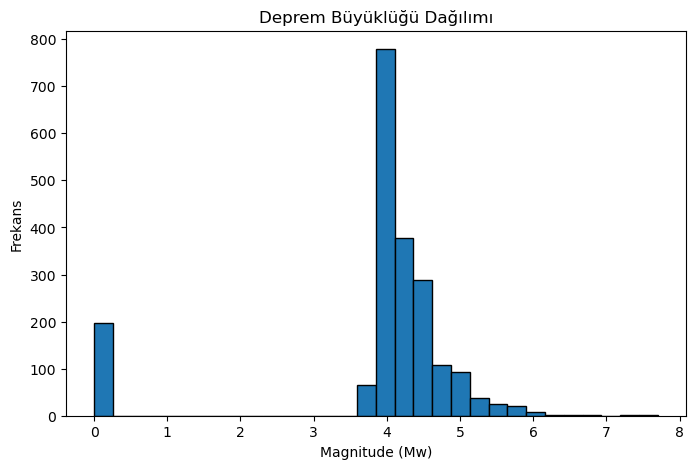

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Magnitude'], bins=30, edgecolor='black')
plt.title("Deprem Büyüklüğü Dağılımı")
plt.xlabel("Magnitude (Mw)")
plt.ylabel("Frekans")
plt.show()

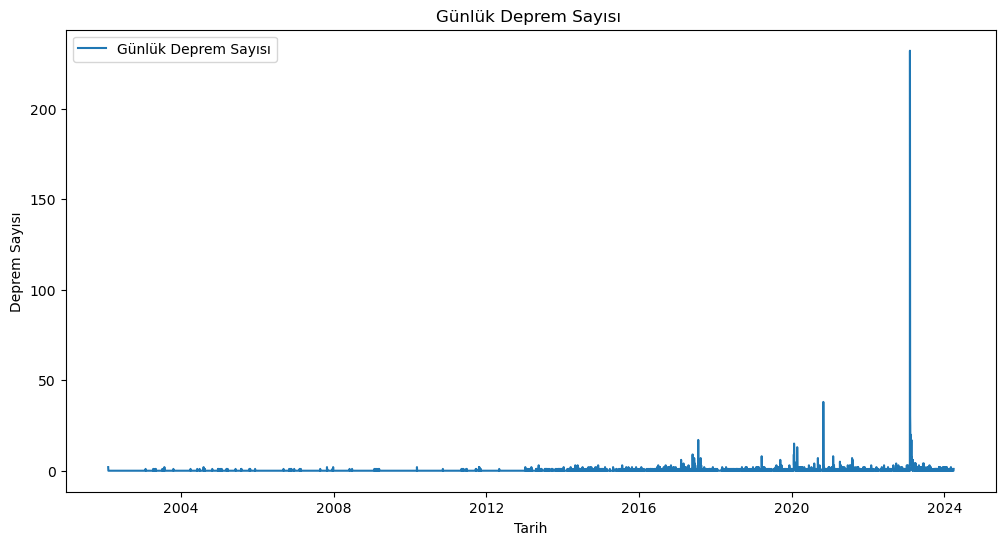

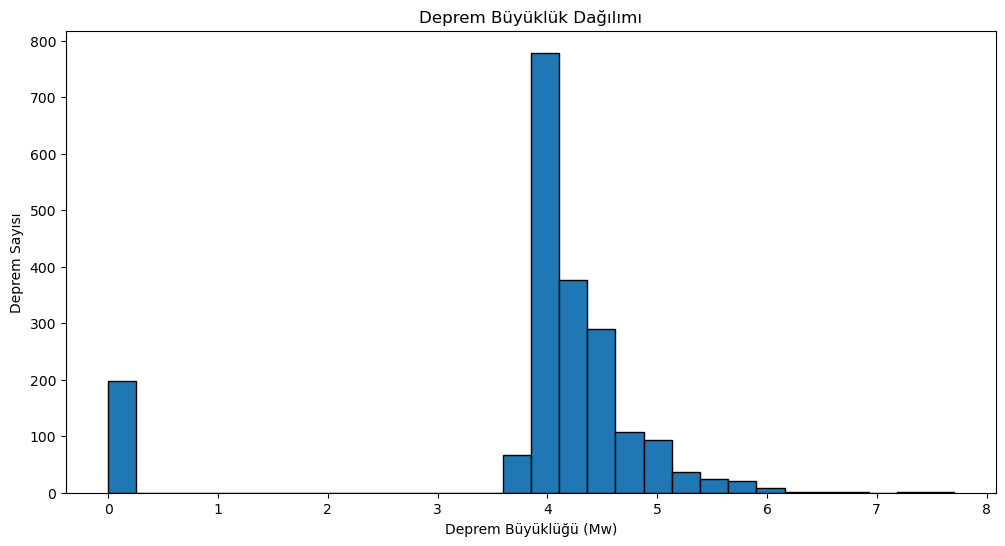

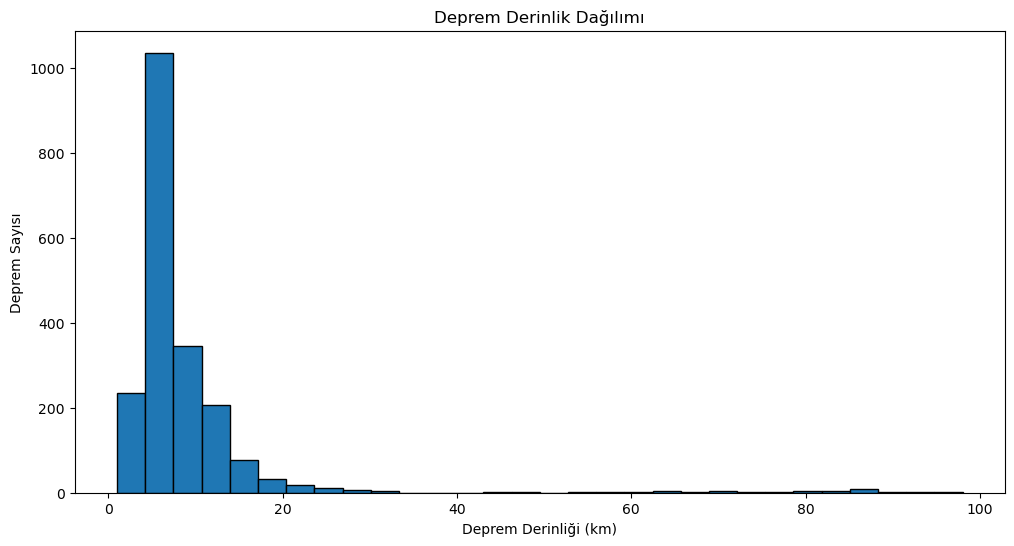

In [21]:
import matplotlib.pyplot as plt

# Günlük deprem sayısını hesaplama
daily_earthquakes = df.resample('D').size()

# Zaman serisini çizme
plt.figure(figsize=(12, 6))
plt.plot(daily_earthquakes, label='Günlük Deprem Sayısı')
plt.xlabel('Tarih')
plt.ylabel('Deprem Sayısı')
plt.title('Günlük Deprem Sayısı ')
plt.legend()
plt.show()

# Büyüklük dağılımını histogram ile görselleştirme
plt.figure(figsize=(12, 6))
plt.hist(df['Magnitude'], bins=30, edgecolor='k')
plt.xlabel('Deprem Büyüklüğü (Mw)')
plt.ylabel('Deprem Sayısı')
plt.title('Deprem Büyüklük Dağılımı')
plt.show()

# Derinlik dağılımını histogram ile görselleştirme
plt.figure(figsize=(12, 6))
plt.hist(df['Depth_km'], bins=30, edgecolor='k')
plt.xlabel('Deprem Derinliği (km)')
plt.ylabel('Deprem Sayısı')
plt.title('Deprem Derinlik Dağılımı')
plt.show()


## ARIMA Modeli ile Günlük Deprem Tahmini

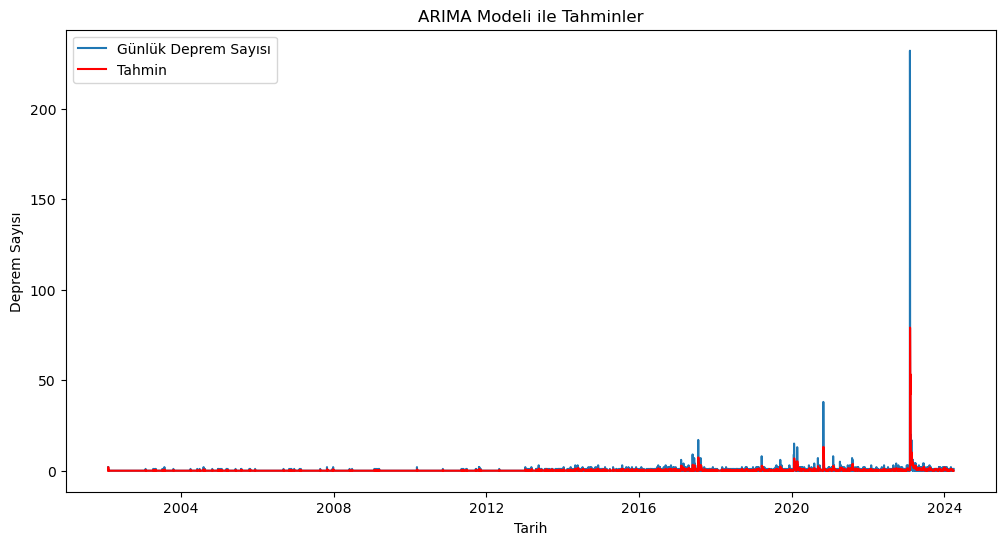

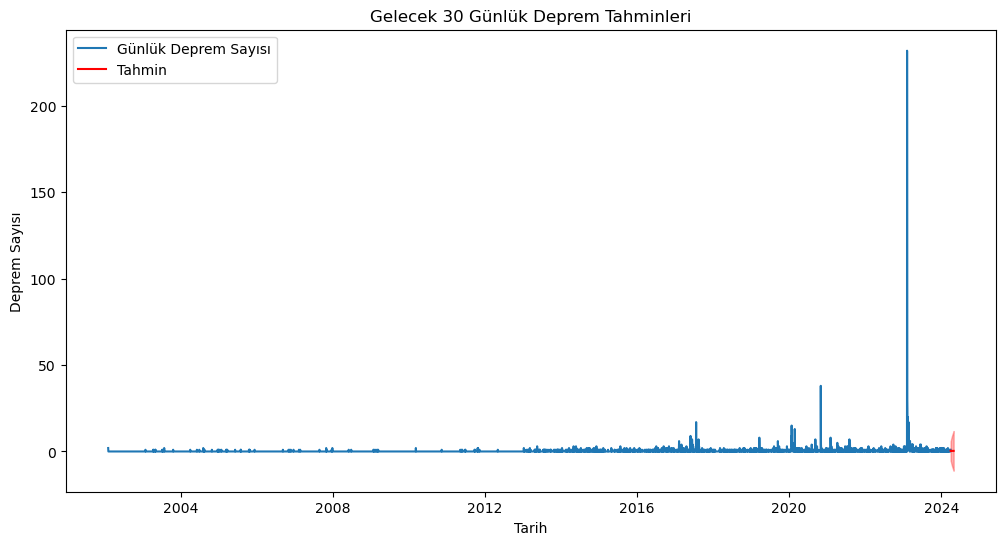

In [22]:
import statsmodels.api as sm

# ARIMA modeli oluşturma ve tahmin
model = sm.tsa.ARIMA(daily_earthquakes, order=(5, 1, 0))
results = model.fit()

# Tahminleri çizme
plt.figure(figsize=(12, 6))
plt.plot(daily_earthquakes, label='Günlük Deprem Sayısı')
plt.plot(results.fittedvalues, color='red', label='Tahmin')
plt.xlabel('Tarih')
plt.ylabel('Deprem Sayısı')
plt.title('ARIMA Modeli ile Tahminler')
plt.legend()
plt.show()

# Gelecek için tahmin yapma
forecast = results.get_forecast(steps=30)
forecast_index = pd.date_range(start=daily_earthquakes.index[-1], periods=30, freq='D')
forecast_values = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

# Tahminleri ve güven aralıklarını çizme
plt.figure(figsize=(12, 6))
plt.plot(daily_earthquakes, label='Günlük Deprem Sayısı')
plt.plot(forecast_index, forecast_values, color='red', label='Tahmin')
plt.fill_between(forecast_index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='red', alpha=0.3)
plt.xlabel('Tarih')
plt.ylabel('Deprem Sayısı')
plt.title('Gelecek 30 Günlük Deprem Tahminleri')
plt.legend()
plt.show()


## SARIMA Modeli

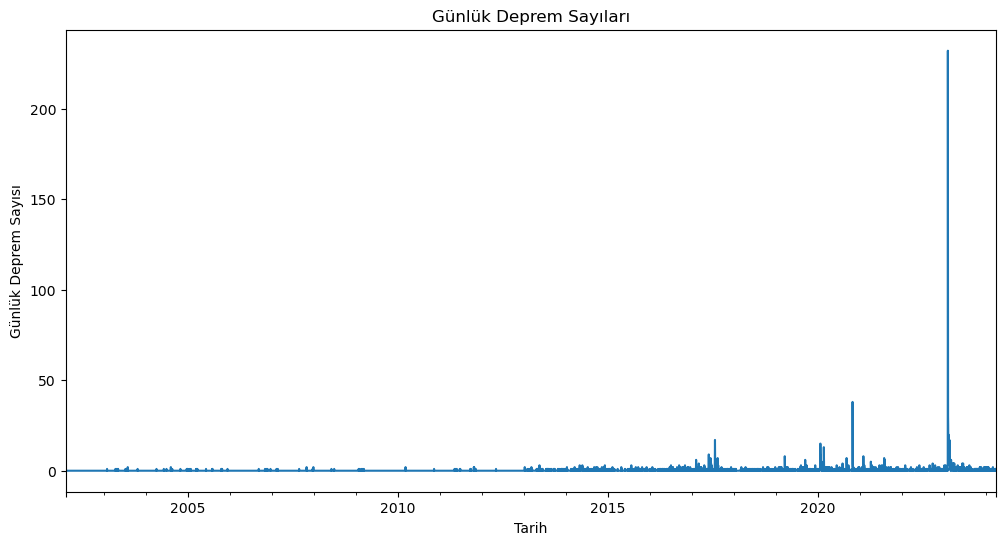

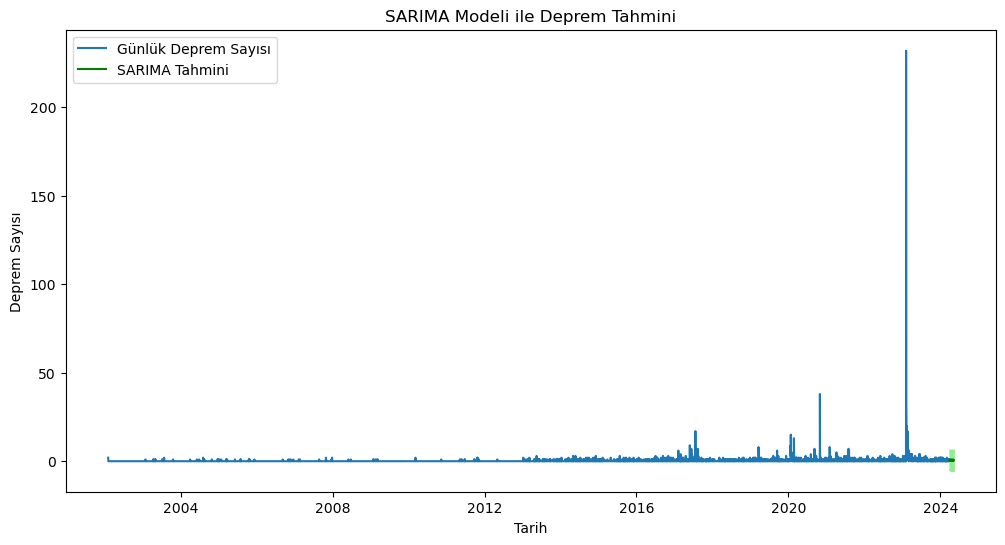

In [23]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Günlük deprem sayısını hesaplama
daily_earthquakes = df['Magnitude'].resample('D').count()

# Mevsimsel etkileri belirlemek için veriyi inceleme
fig, ax = plt.subplots(figsize=(12, 6))
daily_earthquakes.plot(ax=ax)
plt.xlabel('Tarih')
plt.ylabel('Günlük Deprem Sayısı')
plt.title('Günlük Deprem Sayıları')
plt.show()

# SARIMA modelini oluşturma ve eğitme
sarima_model = sm.tsa.statespace.SARIMAX(daily_earthquakes, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_results = sarima_model.fit()

# Tahminleri ve güven aralıklarını alalım
sarima_forecast = sarima_results.get_forecast(steps=40)
sarima_forecast_index = pd.date_range(start=daily_earthquakes.index[-1], periods=40, freq='D')
sarima_forecast_mean = sarima_forecast.predicted_mean
sarima_forecast_ci = sarima_forecast.conf_int()

# Grafik çizme
plt.figure(figsize=(12, 6))
plt.plot(daily_earthquakes.index, daily_earthquakes, label='Günlük Deprem Sayısı')
plt.plot(sarima_forecast_index, sarima_forecast_mean, label='SARIMA Tahmini', color='green')
plt.fill_between(sarima_forecast_index, sarima_forecast_ci.iloc[:, 0], sarima_forecast_ci.iloc[:, 1], color='lightgreen')
plt.xlabel('Tarih')
plt.ylabel('Deprem Sayısı')
plt.title('SARIMA Modeli ile Deprem Tahmini')
plt.legend()
plt.show()


## Deprem Büyüklüğü Tahmini

Latitude, Longitude ve Depth değişkenleri kullanılarak büyüklük tahmini yapılmıştır.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df[['Latitude', 'Longitude', 'Depth_km']]
y = df['Magnitude']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)
gbm.fit(X_train, y_train)

y_pred = gbm.predict(X_test)

print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2:", r2_score(y_test, y_pred))

RMSE: 1.2653476781775432
R2: -0.03740609428879216


## Coğrafi Görselleştirme (GIS Analizi)

Deprem lokasyonları Türkiye haritası üzerinde görselleştirilmiştir.  
Bu analiz, depremlerin mekânsal dağılımını incelemek amacıyla gerçekleştirilmiştir.

C:\Users\Burhan Yasa\AppData\Local\Temp\ipykernel_248\4075049896.py:6: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


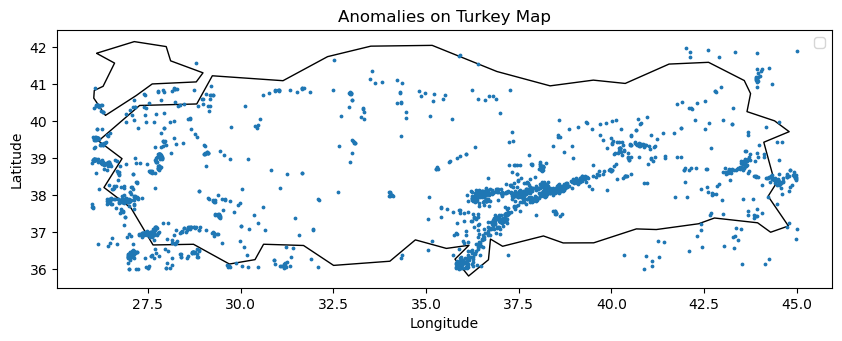

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Dünya haritasını yükleme
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
turkey = world[world['name'] == 'Turkey']

# Deprem noktalarını geometriye dönüştürme
geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
geo_df = gpd.GeoDataFrame(df, geometry=geometry)

# Harita çizimi
fig, ax = plt.subplots(figsize=(10, 6))
turkey.plot(ax=ax, color='white', edgecolor='black')
geo_df.plot(ax=ax, markersize=3)

# Başlık ve etiketler
plt.title('Anomalies on Turkey Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

## Genel Sonuç

Bu çalışmada Türkiye deprem verileri üzerinde kapsamlı bir veri analizi gerçekleştirilmiştir.

Çalışma kapsamında:

- Veri temizleme ve ön işleme adımları uygulanmıştır.
- Deprem büyüklüklerinin dağılımı ve zamansal davranışı incelenmiştir.
- Günlük deprem sayıları ARIMA modeli ile kısa vadeli olarak tahmin edilmiştir.
- Deprem büyüklüğü, konum ve derinlik değişkenleri kullanılarak Gradient Boosting Regressor ile modellenmiştir.
- Depremlerin mekânsal dağılımı GIS araçları ile görselleştirilmiştir.

Elde edilen bulgular, depremlerin hem zamansal hem de mekânsal olarak
belirli örüntüler sergilediğini göstermektedir.

Bu proje, zaman serisi analizi, makine öğrenmesi ve coğrafi veri görselleştirme
tekniklerinin entegre biçimde uygulanmasına bir örnek sunmaktadır.